In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("neo4j_query_table_data_q2.csv")
df.head()

,Country,Topic,Month,MedianSentiment,IndicatorValue
0,DE,Employment,2021-01,-2.880944,3.966667
1,DE,Employment,2021-02,-0.715143,4.000000
2,DE,Employment,2021-03,-1.409013,3.933333
3,DE,Employment,2021-04,-2.306211,3.833333
4,DE,Employment,2021-05,-0.860681,3.700000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          220 non-null    object 
 1   Topic            220 non-null    object 
 2   Month            220 non-null    object 
 3   MedianSentiment  220 non-null    float64
 4   IndicatorValue   220 non-null    float64
dtypes: float64(2), object(3)
memory usage: 8.7+ KB


In [ ]:
df.describe()

,MedianSentiment,IndicatorValue
count,220.000000,220.000000
mean,-1.705266,78.839720
std,1.880168,62.022357
min,-11.065574,2.966667
25%,-2.519595,7.133333
50%,-1.549388,91.600000
75%,-0.805546,136.683333
max,3.804994,158.033333


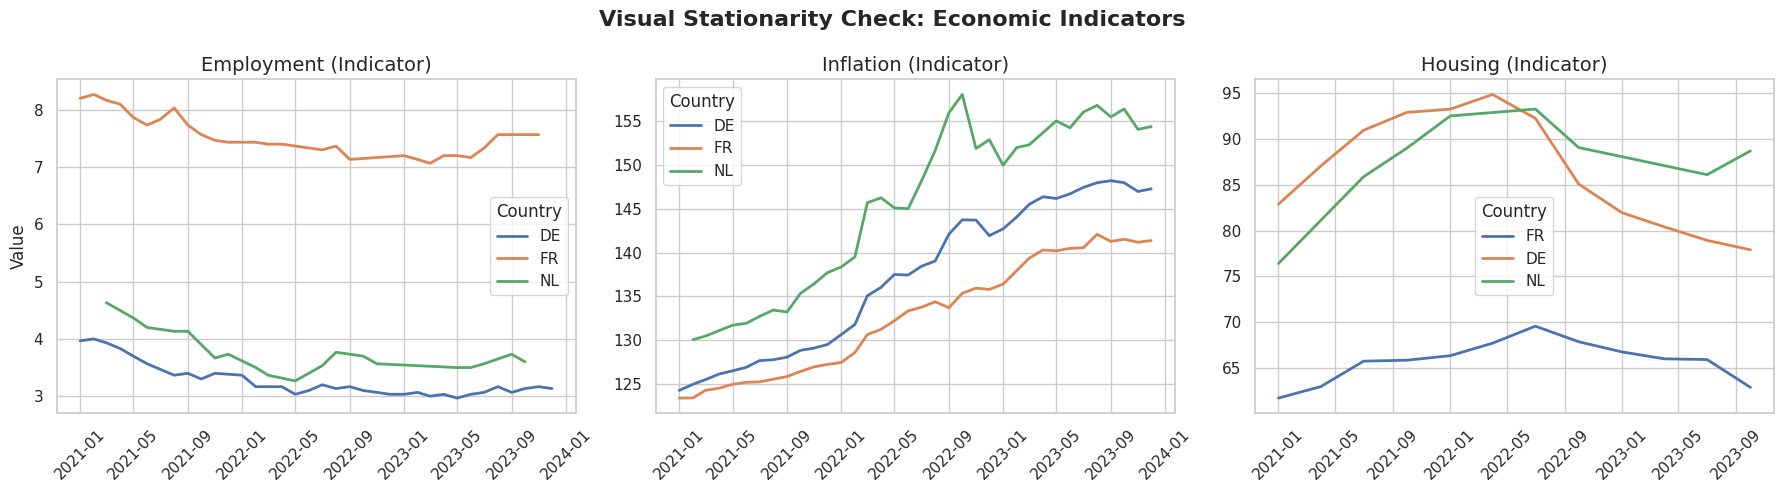

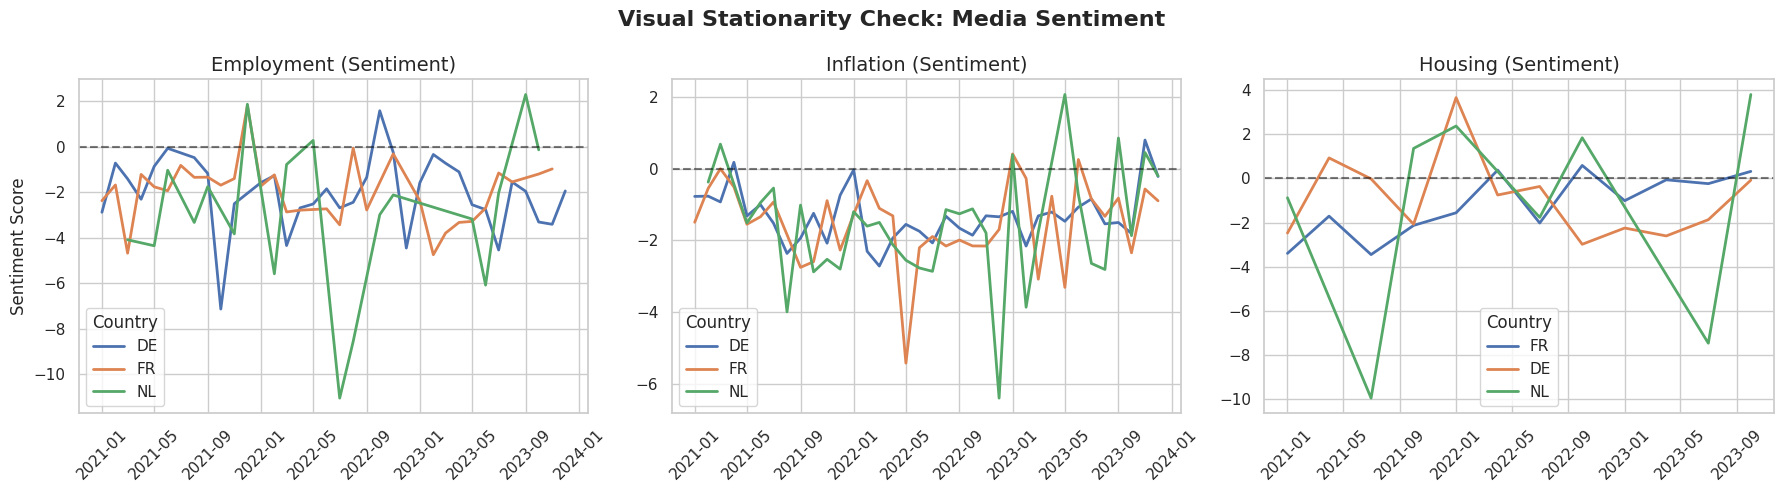

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


df['Month'] = pd.to_datetime(df['Month'])

# Sort by Date just in case
df = df.sort_values('Month')

# Get the unique topics directly from the data
topics = df['Topic'].unique()

# Set a clean visual style
sns.set_theme(style="whitegrid")

# Chart set 1: Economic Indicators
fig1, axes1 = plt.subplots(1, len(topics), figsize=(18, 5))
fig1.suptitle('Visual Stationarity Check: Economic Indicators', fontsize=16, fontweight='bold')

for i, topic in enumerate(topics):
    topic_data = df[df['Topic'] == topic]
    sns.lineplot(data=topic_data, x='Month', y='IndicatorValue', hue='Country', ax=axes1[i], linewidth=2)

    axes1[i].set_title(f'{topic} (Indicator)', fontsize=14)
    axes1[i].tick_params(axis='x', rotation=45)
    axes1[i].set_xlabel('')
    axes1[i].set_ylabel('Value' if i == 0 else '')

plt.tight_layout()
plt.show()

# Chart Set 2: Media Sentiment
fig2, axes2 = plt.subplots(1, len(topics), figsize=(18, 5))
fig2.suptitle('Visual Stationarity Check: Media Sentiment', fontsize=16, fontweight='bold')

for i, topic in enumerate(topics):
    topic_data = df[df['Topic'] == topic]
    sns.lineplot(data=topic_data, x='Month', y='MedianSentiment', hue='Country', ax=axes2[i], linewidth=2)

    axes2[i].axhline(0, color='black', linestyle='--', alpha=0.5)

    axes2[i].set_title(f'{topic} (Sentiment)', fontsize=14)
    axes2[i].tick_params(axis='x', rotation=45)
    axes2[i].set_xlabel('')
    axes2[i].set_ylabel('Sentiment Score' if i == 0 else '')

plt.tight_layout()
plt.show()



# Check for stationarity

In [ ]:
from statsmodels.tsa.stattools import adfuller

def run_adf_tests(dataframe):
    results = []

    # Get unique countries and topics
    countries = dataframe['Country'].unique()
    topics = dataframe['Topic'].unique()

    for country in countries:
        for topic in topics:
            # Isolate the specific 3-year timeline for this exact country & topic
            subset = dataframe[(dataframe['Country'] == country) & (dataframe['Topic'] == topic)]

            # Skip if there's missing data
            if subset.empty:
                continue

            # Test Sentiment
            sent_pval = adfuller(subset['MedianSentiment'].dropna())[1]
            sent_stationary = "Yes" if sent_pval < 0.05 else "No (Needs Diff)"

            # Test Economic Indicator
            ind_pval = adfuller(subset['IndicatorValue'].dropna())[1]
            ind_stationary = "Yes" if ind_pval < 0.05 else "No (Needs Diff)"

            # Save the results
            results.append({
                'Country': country,
                'Topic': topic,
                'Sentiment Stationary?': sent_stationary,
                'Sentiment p-value': round(sent_pval, 4),
                'Indicator Stationary?': ind_stationary,
                'Indicator p-value': round(ind_pval, 4)
            })

    # Convert results into a summary DataFrame
    results_df = pd.DataFrame(results)
    return results_df

# Run the test and print the table
adf_summary_table = run_adf_tests(df)
print(adf_summary_table.to_string(index=False))

Country      Topic Sentiment Stationary?  Sentiment p-value Indicator Stationary?  Indicator p-value
     DE Employment                   Yes             0.0100       No (Needs Diff)             0.0631
     DE  Inflation                   Yes             0.0102       No (Needs Diff)             0.6896
     DE    Housing       No (Needs Diff)             0.5973       No (Needs Diff)             0.1097
     FR Employment                   Yes             0.0003       No (Needs Diff)             0.2708
     FR  Inflation                   Yes             0.0000       No (Needs Diff)             0.8427
     FR    Housing       No (Needs Diff)             0.1935                   Yes             0.0000
     NL Employment                   Yes             0.0063       No (Needs Diff)             0.0777
     NL  Inflation                   Yes             0.0000       No (Needs Diff)             0.5797
     NL    Housing                   Yes             0.0090                   Yes          

# Data transformations to make the time-series data stationary

In [ ]:

print("--- Step 1: Data Cleaning & Interpolation ---")

# Ensure Month is datetime
df['Month'] = pd.to_datetime(df['Month'])
df = df.sort_values(by=['Country', 'Topic', 'Month'])

clean_data = []
start_date = df['Month'].min()
end_date = df['Month'].max()
full_timeline = pd.date_range(start=start_date, end=end_date, freq='MS')

# Loop through and force the missing months to generate, then fill them
for country in df['Country'].unique():
    for topic in df['Topic'].unique():
        subset = df[(df['Country'] == country) & (df['Topic'] == topic)].copy()
        if subset.empty: continue

        subset = subset.set_index('Month')
        subset = subset.reindex(full_timeline)

        # Fill missing values using linear interpolation
        subset['IndicatorValue'] = subset['IndicatorValue'].interpolate(method='linear')
        subset['MedianSentiment'] = subset['MedianSentiment'].interpolate(method='linear')

        subset['Country'] = country
        subset['Topic'] = topic
        subset = subset.reset_index().rename(columns={'index': 'Month'})

        clean_data.append(subset)

df_clean = pd.concat(clean_data, ignore_index=True)
print("Timeline repaired! Missing months filled via interpolation.\n")

print("--- Step 2: Applying Transformations & Dynamic Differencing ---")

df_final = df_clean.copy()

for index, row in adf_summary_table.iterrows():
    country = row['Country']
    topic = row['Topic']

    mask = (df_final['Country'] == country) & (df_final['Topic'] == topic)
    subset = df_final[mask]

    # Transform Sentiment (Simple Diff)
    if row['Sentiment Stationary?'] == 'No (Needs Diff)':
        df_final.loc[mask, 'MedianSentiment'] = subset['MedianSentiment'].diff()

    # Transform Indicator (Log + Dynamic Diff)
    if row['Indicator Stationary?'] == 'No (Needs Diff)':
        # Attempt 1: First-order Log-Return
        first_diff = np.log(subset['IndicatorValue']).diff()

        # Test the first difference immediately (dropping the 1st row NaN)
        pval = adfuller(first_diff.dropna())[1]

        if pval < 0.05:
            df_final.loc[mask, 'IndicatorValue'] = first_diff
            print(f"[OK] {country} - {topic:<10} Indicator: Stationary after 1st Log-Diff")
        else:
            # First difference failed. Apply second difference!
            df_final.loc[mask, 'IndicatorValue'] = first_diff.diff()
            print(f"[I2] {country} - {topic:<10} Indicator: Applied 2nd Order Differencing")

# Drop the NaN values created by the differencing
df_final = df_final.dropna(subset=['MedianSentiment', 'IndicatorValue'])

print("\n--- Step 3: Final Verification Check ---")
all_passed = True

for index, row in adf_summary_table.iterrows():
    country = row['Country']
    topic = row['Topic']
    mask = (df_final['Country'] == country) & (df_final['Topic'] == topic)

    # Double check the indicators that were modified
    if row['Indicator Stationary?'] == 'No (Needs Diff)':
        final_pval = adfuller(df_final.loc[mask, 'IndicatorValue'])[1]
        if final_pval >= 0.05:
            print(f"WARNING: {country} {topic} still not stationary! p={final_pval:.4f}")
            all_passed = False

if all_passed:
    print("\n✅ SUCCESS! All 9 time series pairs are completely stationary.")
    print("Your 'df_final' dataframe is mathematically cleared to run the Lead/Lag analysis!")

--- Step 1: Data Cleaning & Interpolation ---
Timeline repaired! Missing months filled via interpolation.

--- Step 2: Applying Transformations & Dynamic Differencing ---
[OK] DE - Employment Indicator: Stationary after 1st Log-Diff
[I2] DE - Inflation  Indicator: Applied 2nd Order Differencing
[I2] DE - Housing    Indicator: Applied 2nd Order Differencing
[OK] FR - Employment Indicator: Stationary after 1st Log-Diff
[OK] FR - Inflation  Indicator: Stationary after 1st Log-Diff
[OK] NL - Employment Indicator: Stationary after 1st Log-Diff
[OK] NL - Inflation  Indicator: Stationary after 1st Log-Diff

--- Step 3: Final Verification Check ---

✅ SUCCESS! All 9 time series pairs are completely stationary.
Your 'df_final' dataframe is mathematically cleared to run the Lead/Lag analysis!


# Calculate and visualize cross correlation function (correlogram) between media sentiment and economic indicator value per topic and country

- **Negative lag:** the economic indicator leads sentiment (media reacts after the fact)
- **Positive lag:** sentiment leads the indicator (media predicts future economic conditions)
- **Dashed lines:** bounds for statistical significance

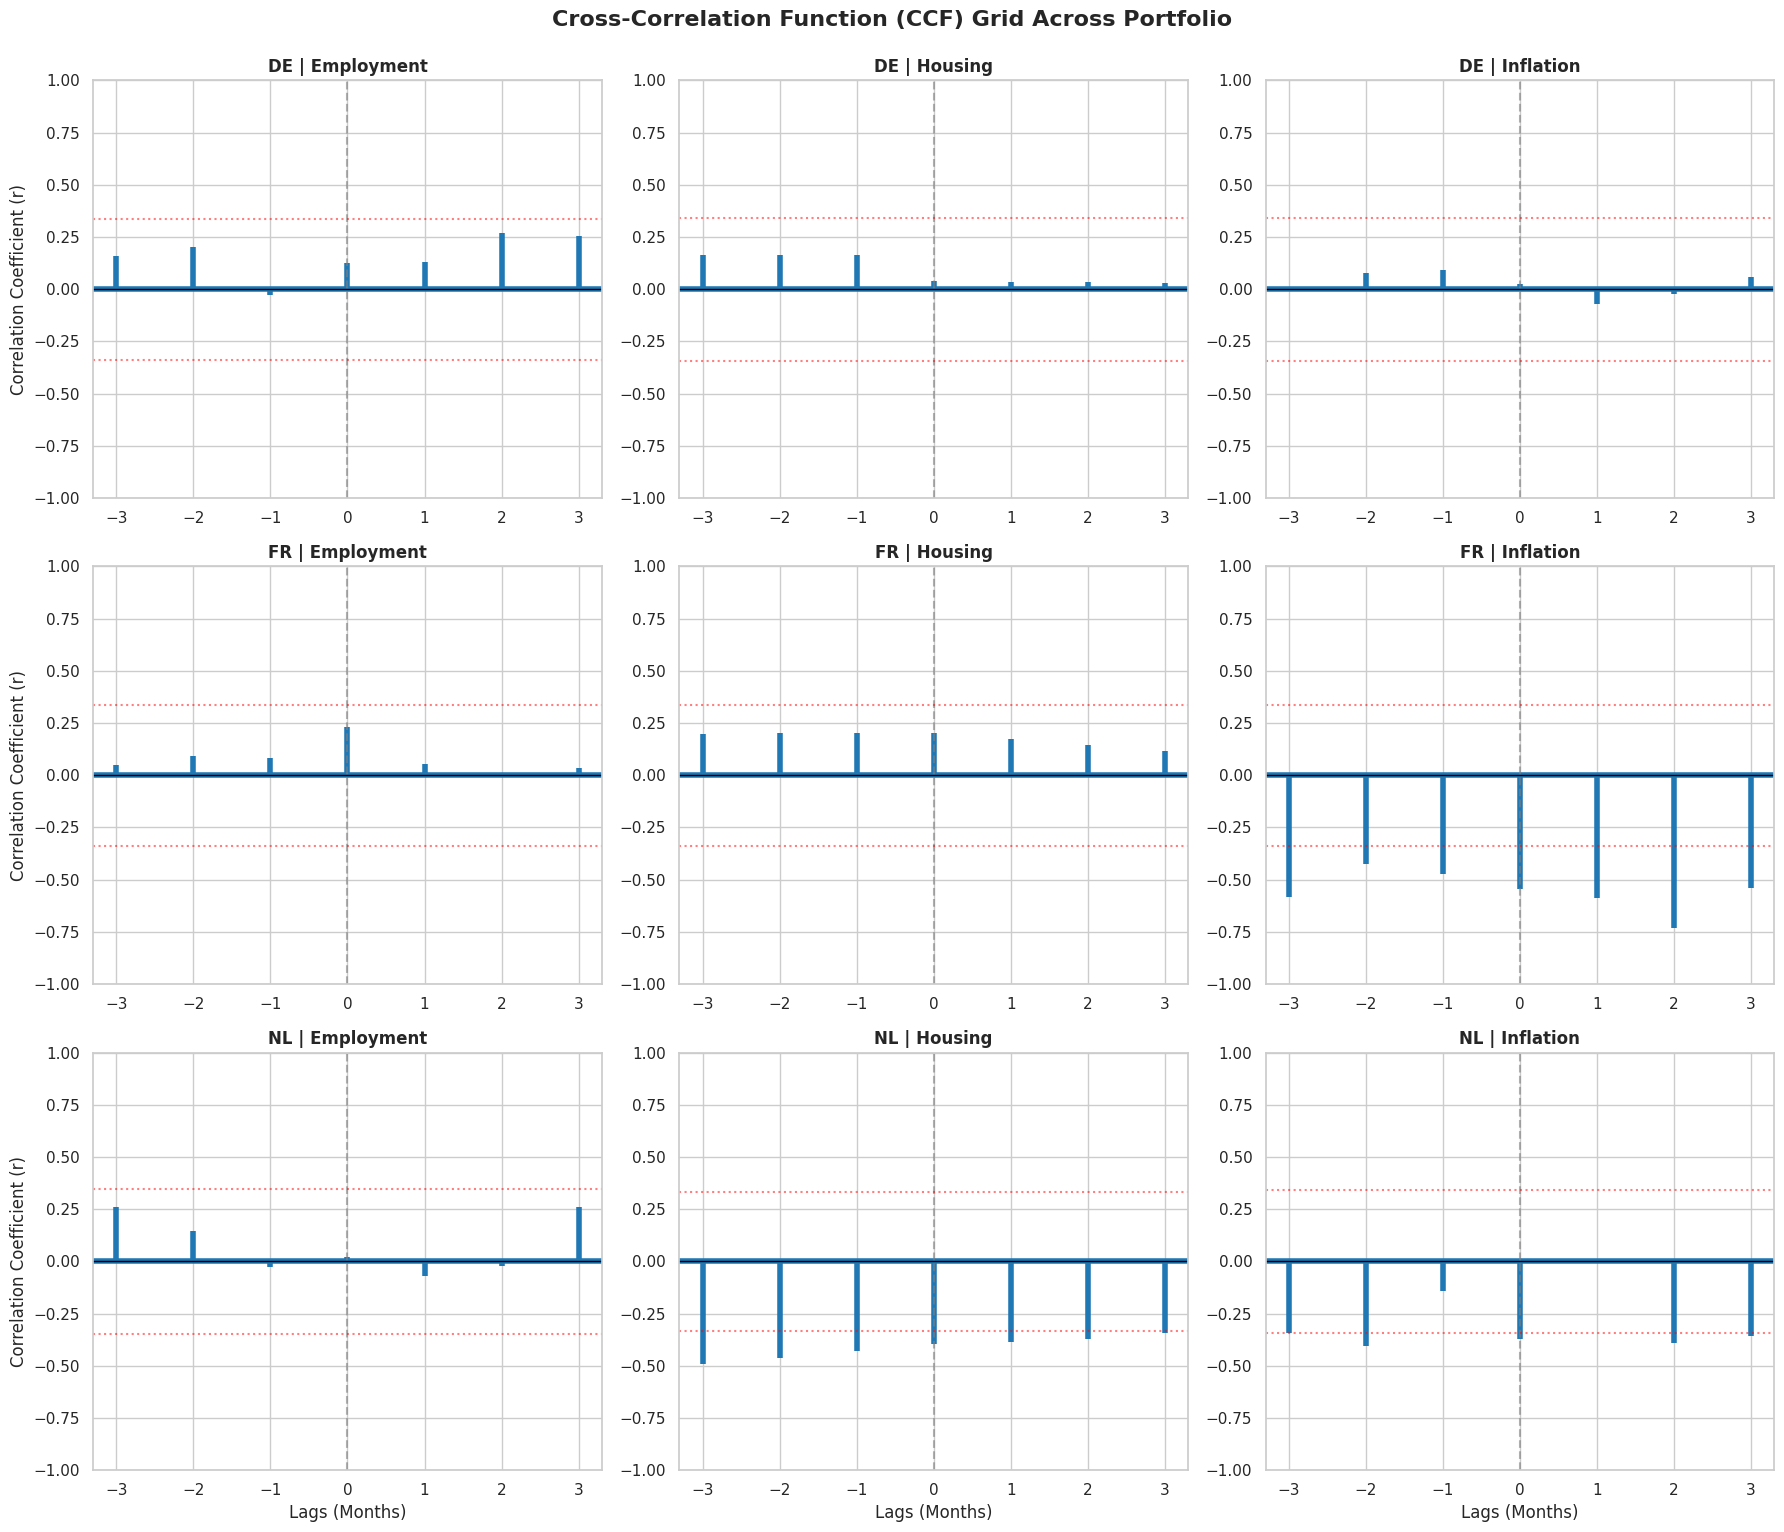

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import ccf

sns.set_theme(style="whitegrid")

# Max months to look forward/backward
MAX_LAGS = 3

ccf_results = []

# Setup a 3x3 plot grid for all Country-Topic combinations
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
countries = df_final['Country'].unique()
topics = df_final['Topic'].unique()

# Map grid coordinates
country_map = {country: idx for idx, country in enumerate(countries)}
topic_map = {topic: idx for idx, topic in enumerate(topics)}

for (country, topic), group in df_final.groupby(['Country', 'Topic']):
    # Sort just to be absolutely safe for time continuity
    group = group.sort_values('Month')

    x = group['MedianSentiment'].values
    y = group['IndicatorValue'].values

    # Get the correct subplot based on country and topic
    r, c = country_map[country], topic_map[topic]
    ax = axes[r, c]

    # xcorr handles the full cross-correlation calculation and plotting natively
    ax.xcorr(x, y, maxlags=MAX_LAGS, usevlines=True, normed=True, lw=4, color='#1f77b4')

    ax.set_title(f"{country} | {topic}", fontsize=12, fontweight='bold')
    ax.set_ylim(-1.0, 1.0)
    ax.axhline(0, color='black', lw=1)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.6)

    # Add a 95% confidence boundary line for significance testing
    # Formula for standard error of cross-correlation is approx 2 / sqrt(N)
    n = len(group)
    conf_level = 2.0 / np.sqrt(n)
    ax.axhline(conf_level, color='red', linestyle=':', alpha=0.5, label='95% Conf.')
    ax.axhline(-conf_level, color='red', linestyle=':', alpha=0.5)

    # Context axis labels for presentation clarity
    if r == 2: ax.set_xlabel("Lags (Months)")
    if c == 0: ax.set_ylabel("Correlation Coefficient (r)")

plt.tight_layout()
plt.suptitle("Cross-Correlation Function (CCF) Grid Across Portfolio", y=1.02, fontsize=16, fontweight='bold')
plt.show()